In [1]:
import os
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1778050026.112456    1251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778050029.154746    1251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf
print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU ready")

GPU ready


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = 'facial expression classification/train'
VAL_DIR   = 'facial expression classification/validation'
TEST_DIR  = 'facial expression classification/test'
IMG_SIZE  = (48, 48)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)
classes = list(train_generator.class_indices.keys())

print("Train batches:", len(train_generator))
print("Val batches:  ", len(val_generator))
print("Test batches: ", len(test_generator))
print("Classes:", classes)
print("NUM_CLASSES:", NUM_CLASSES)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train batches: 840
Val batches:   221
Test batches:  60
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES: 7


In [5]:
from keras import Input
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_baseline(num_classes):
    model = Sequential([
        Input(shape=(48, 48, 3)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline = build_baseline(NUM_CLASSES)
baseline.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,759 (5.02 MB)

 Trainable params: 1,314,759 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import os

for split in ['train', 'validation', 'test']:
    path = f'facial expression classification/{split}'
    if os.path.exists(path):
        total = sum(len(files) for _, _, files in os.walk(path))
        classes = [d for d in os.listdir(path) if os.path.isdir(f'{path}/{d}')]
        print(f"{split}: {total} files, {len(classes)} classes")
    else:
        print(f"{split}: NOT FOUND")

train: 26872 files, 7 classes
validation: 7080 files, 7 classes
test: 1900 files, 7 classes


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = 'facial expression classification/train'
VAL_DIR   = 'facial expression classification/validation'
TEST_DIR  = 'facial expression classification/test'
IMG_SIZE  = (48, 48)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Train batches:", len(train_generator))
print("Val batches:  ", len(val_generator))
print("Test batches: ", len(test_generator))
print("Classes:", train_generator.class_indices)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train batches: 840
Val batches:   221
Test batches:  60
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [8]:
base_dir  = 'facial expression classification'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')
test_dir  = os.path.join(base_dir, 'test')

classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])

NUM_CLASSES = len(classes)
IMG_SIZE    = (48, 48)
BATCH_SIZE  = 64

print('Classes     :', classes)
print('NUM_CLASSES :', NUM_CLASSES)

Classes     : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES : 7


In [9]:
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')
corrupted_files  = []
checked          = 0

for split_dir in [train_dir, val_dir, test_dir]:
    for cls in classes:
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            checked += 1

            if checked % 1000 == 0:
                print(f'Checked {checked} files so far ...')

            if not fname.lower().endswith(valid_extensions):
                corrupted_files.append(fpath)
                continue

            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                corrupted_files.append(fpath)

print(f'Finished checking {checked} total files')
print(f'Corrupted or invalid files found : {len(corrupted_files)}')

for fpath in corrupted_files:
    os.remove(fpath)
    print(f'Removed : {fpath}')

print(f'Total files removed : {len(corrupted_files)}')

Checked 1000 files so far ...
Checked 2000 files so far ...
Checked 3000 files so far ...
Checked 4000 files so far ...
Checked 5000 files so far ...
Checked 6000 files so far ...
Checked 7000 files so far ...
Checked 8000 files so far ...
Checked 9000 files so far ...
Checked 10000 files so far ...
Checked 11000 files so far ...
Checked 12000 files so far ...
Checked 13000 files so far ...
Checked 14000 files so far ...
Checked 15000 files so far ...
Checked 16000 files so far ...
Checked 17000 files so far ...
Checked 18000 files so far ...
Checked 19000 files so far ...
Checked 20000 files so far ...
Checked 21000 files so far ...
Checked 22000 files so far ...
Checked 23000 files so far ...
Checked 24000 files so far ...
Checked 25000 files so far ...
Checked 26000 files so far ...
Checked 27000 files so far ...
Checked 28000 files so far ...
Checked 29000 files so far ...
Checked 30000 files so far ...
Checked 31000 files so far ...
Checked 32000 files so far ...
Checked 33000 fil

In [10]:
def count_images(directory, classes):
    """
    Count the number of images in each class subdirectory.

    Parameters
    ----------
    directory : str
        Path to the split directory.
    classes : list
        List of class folder names.

    Returns
    -------
    dict
        Dictionary mapping class name to image count.
    """
    return {
        cls: len([
            f for f in os.listdir(os.path.join(directory, cls))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for cls in classes
    }

train_counts = count_images(train_dir, classes)
val_counts   = count_images(val_dir,   classes)
test_counts  = count_images(test_dir,  classes)

print('Training Distribution:')
for cls, count in train_counts.items():
    print(f'  {cls:<15} : {count}')

print('\nValidation Distribution:')
for cls, count in val_counts.items():
    print(f'  {cls:<15} : {count}')

print('\nTest Distribution:')
for cls, count in test_counts.items():
    print(f'  {cls:<15} : {count}')

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

print('\nDataset Summary')
print(f'  Total Train      : {total_train}')
print(f'  Total Validation : {total_val}')
print(f'  Total Test       : {total_test}')
print(f'  Grand Total      : {total_train + total_val + total_test}')

Training Distribution:
  angry           : 3686
  disgust         : 329
  fear            : 3796
  happy           : 6857
  neutral         : 4675
  sad             : 4631
  surprise        : 2898

Validation Distribution:
  angry           : 960
  disgust         : 111
  fear            : 1018
  happy           : 1825
  neutral         : 1216
  sad             : 1139
  surprise        : 797

Test Distribution:
  angry           : 300
  disgust         : 100
  fear            : 300
  happy           : 300
  neutral         : 300
  sad             : 300
  surprise        : 300

Dataset Summary
  Total Train      : 26872
  Total Validation : 7066
  Total Test       : 1900
  Grand Total      : 35838


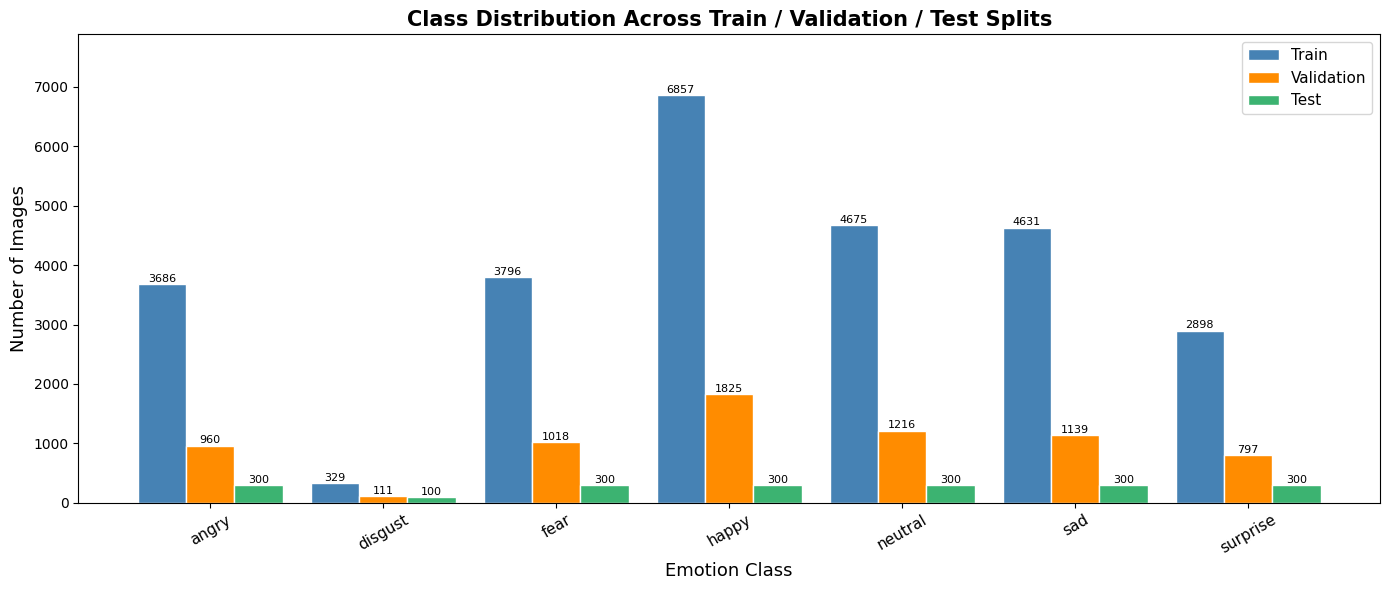

In [11]:
x     = np.arange(len(classes))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))

bars_train = ax.bar(x - width, list(train_counts.values()),
                    width, label='Train',      color='steelblue',      edgecolor='white')
bars_val   = ax.bar(x,          list(val_counts.values()),
                    width, label='Validation', color='darkorange',     edgecolor='white')
bars_test  = ax.bar(x + width,  list(test_counts.values()),
                    width, label='Test',       color='mediumseagreen', edgecolor='white')

for bar_group in [bars_train, bars_val, bars_test]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height + 5,
                str(int(height)), ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Emotion Class',    fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('Class Distribution Across Train / Validation / Test Splits',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(train_counts.values()) * 1.15)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

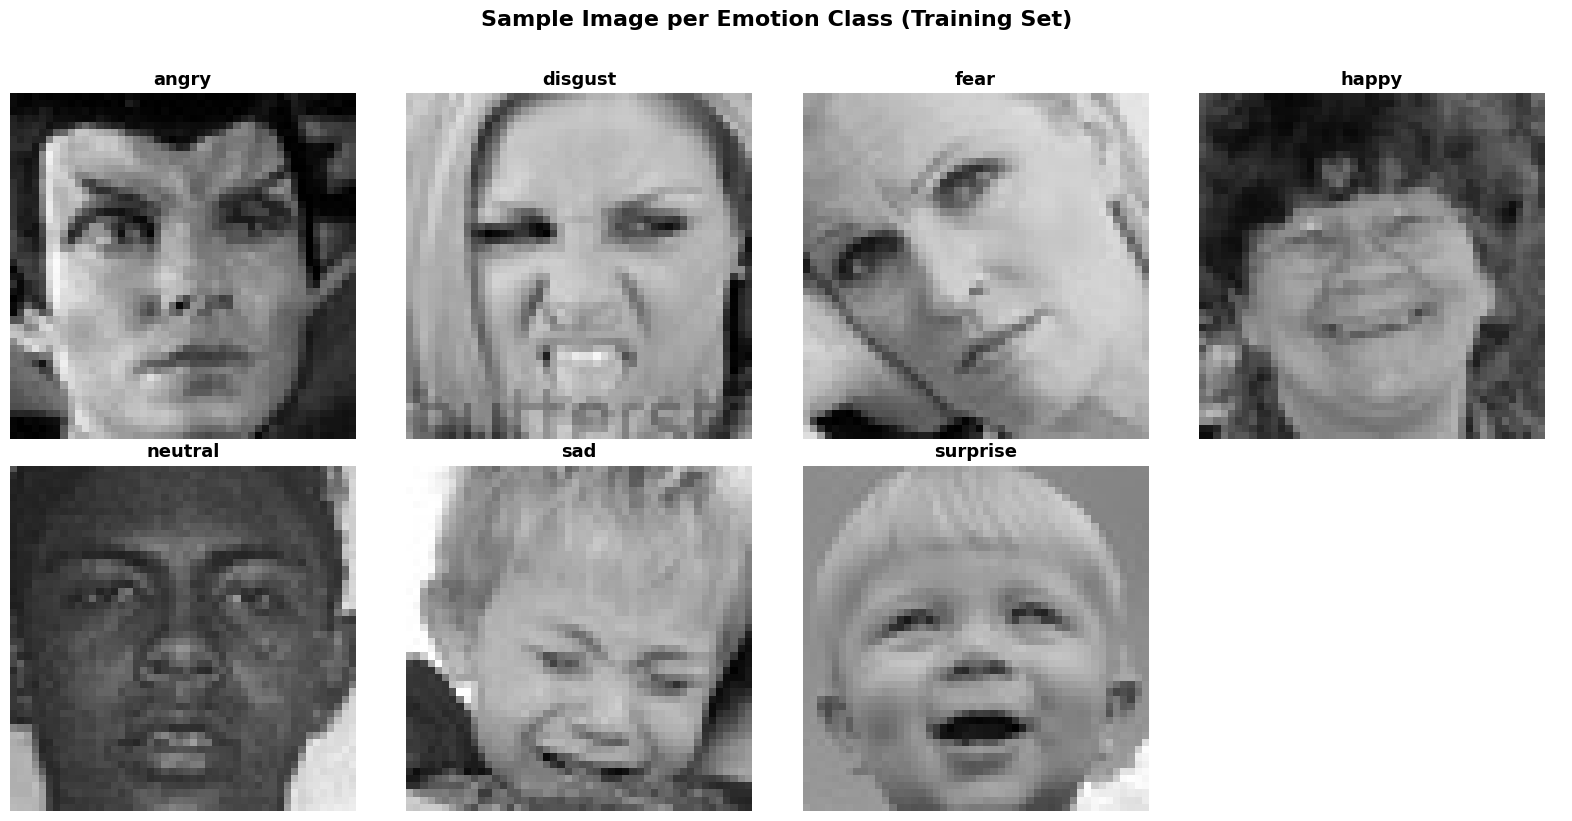

In [12]:
n_classes = len(classes)
n_cols    = 4
n_rows    = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes      = axes.flatten()

for i, cls in enumerate(classes):
    cls_path    = os.path.join(train_dir, cls)
    image_files = [f for f in os.listdir(cls_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = Image.open(os.path.join(cls_path, image_files[0])).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].axis('off')

for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Image per Emotion Class (Training Set)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

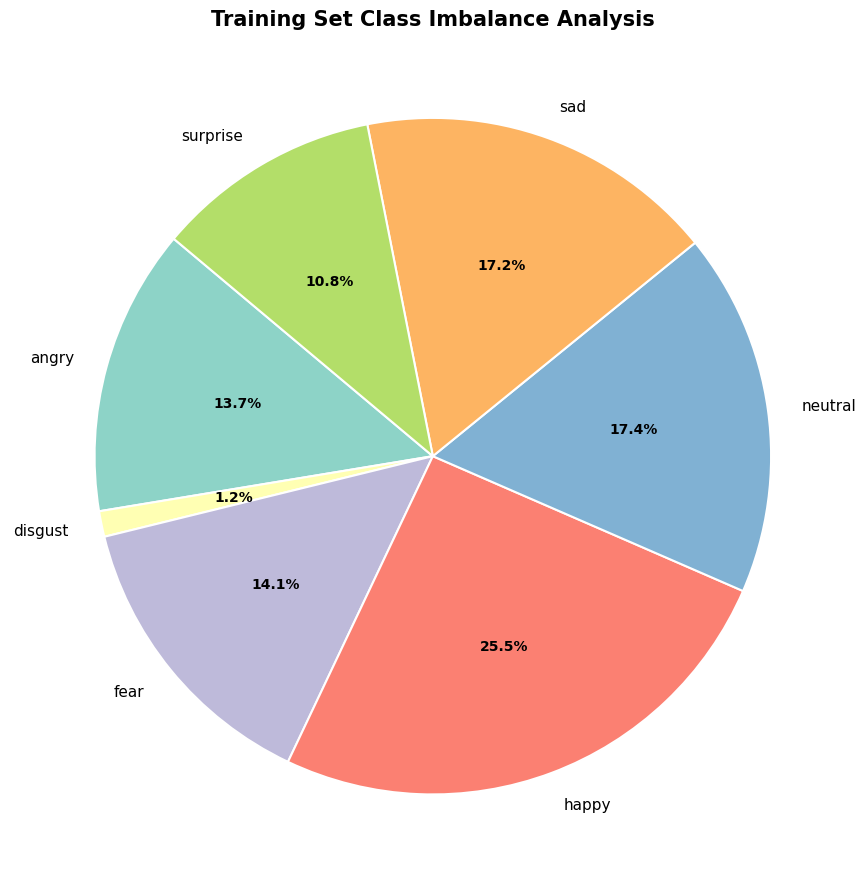

Class Imbalance Report
  Largest class   : happy (6857 images)
  Smallest class  : disgust (329 images)
  Imbalance ratio : 20.84x


In [13]:
fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    list(train_counts.values()),
    labels=classes,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:n_classes],
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Training Set Class Imbalance Analysis',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('class_imbalance_pie.png', dpi=150)
plt.show()

max_class = max(train_counts, key=train_counts.get)
min_class = min(train_counts, key=train_counts.get)
ratio     = train_counts[max_class] / train_counts[min_class]

print('Class Imbalance Report')
print(f'  Largest class   : {max_class} ({train_counts[max_class]} images)')
print(f'  Smallest class  : {min_class} ({train_counts[min_class]} images)')
print(f'  Imbalance ratio : {ratio:.2f}x')

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True
)

val_generator = eval_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

print(f'Train      : {train_generator.samples}')
print(f'Validation : {val_generator.samples}')
print(f'Test       : {test_generator.samples}')

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Train      : 26872
Validation : 7066
Test       : 1900


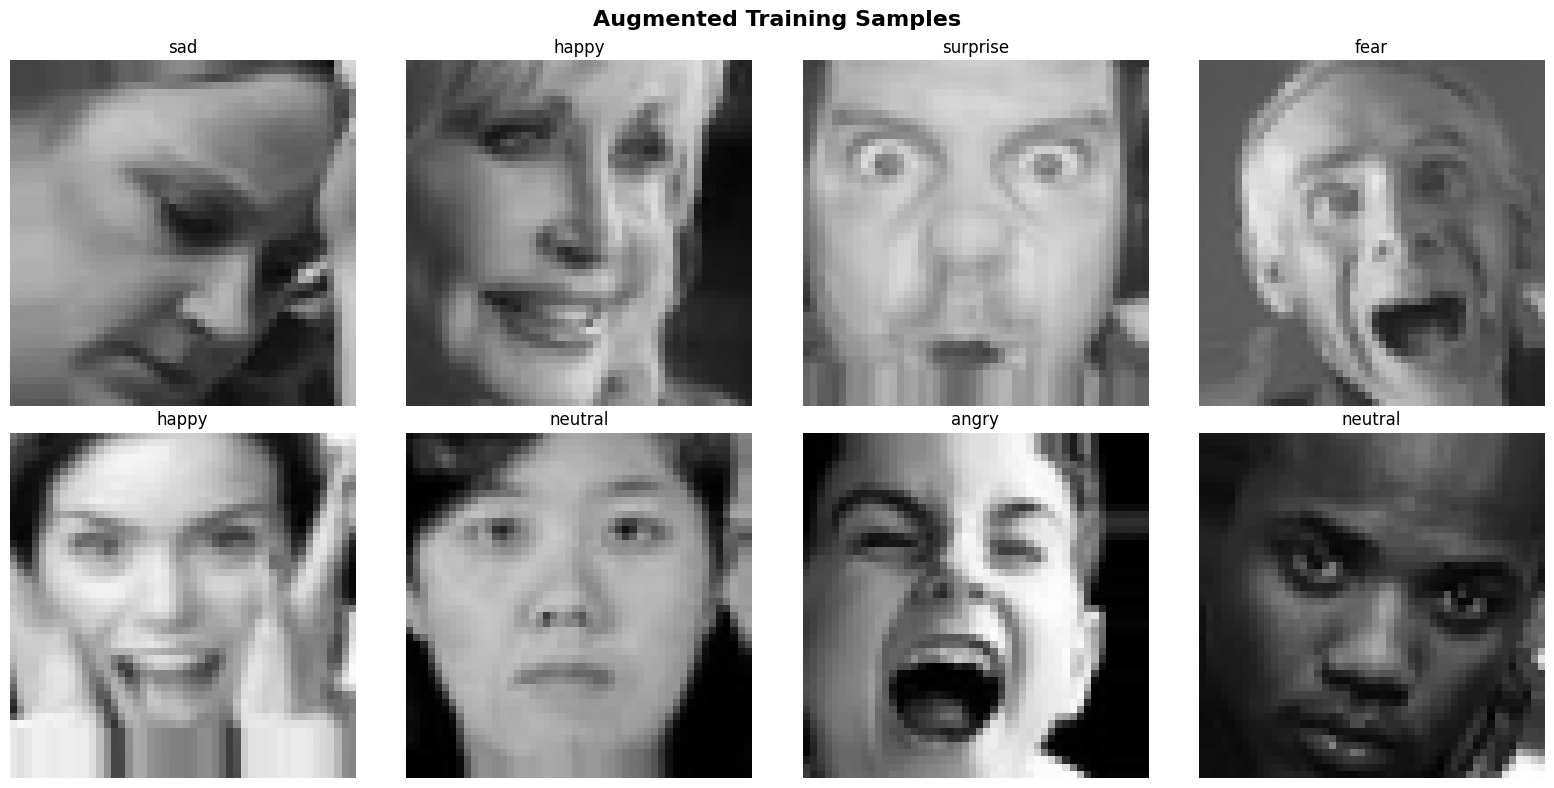

In [15]:
sample_imgs, sample_lbls = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.set_title(classes[np.argmax(sample_lbls[i])], fontsize=12)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

In [16]:
def plot_history(history, title):
    """Plot training and validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, generator, classes, title):
    """Evaluate model and display confusion matrix and classification report."""
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = generator.classes
    acc          = accuracy_score(y_true, y_pred)

    print(f'\nEvaluation Report : {title}')
    print(f'Test Accuracy     : {acc * 100:.2f}%')
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=10)
    plt.yticks(tick_marks, classes, fontsize=10)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black',
                 fontsize=9)
    plt.ylabel('True Label',      fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()

    return y_true, y_pred, acc

print('Helper functions defined successfully')


def make_train_callbacks(patience=10, lr_patience=5, min_lr=1e-6):
    """Create fresh callbacks for each model fit.

    Keras callbacks keep internal state after training. Reusing the same
    EarlyStopping object across models can restore weights from the wrong run.
    """
    return [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=lr_patience, min_lr=min_lr, verbose=1)
    ]


Helper functions defined successfully


In [17]:
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Fix CUDA memory fragmentation — add this BEFORE building any model
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found: {gpus}")
    except RuntimeError as e:
        print(e)

def build_baseline(num_classes):
    model = Sequential([
        Input(shape=(48, 48, 3)),          # ← explicit Input layer (Keras 3 style)
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline = build_baseline(NUM_CLASSES)
baseline.summary()

GPU(s) found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,759 (5.02 MB)

 Trainable params: 1,314,759 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 55s 99ms/step - accuracy: 0.2654 - loss: 1.7653 - val_accuracy: 0.3282 - val_loss: 1.6792 - learning_rate: 0.0010
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.3590 - loss: 1.6154 - val_accuracy: 0.4437 - val_loss: 1.4275 - learning_rate: 0.0010
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4343 - loss: 1.4510 - val_accuracy: 0.4905 - val_loss: 1.3240 - learning_rate: 0.0010
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.4779 - loss: 1.3578 - val_accuracy: 0.5185 - val_loss: 1.2687 - learning_rate: 0.0010
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4999 - loss: 1.2997 - val_accuracy: 0.5412 - val_loss: 1.2000 - learning_rate: 0.0010
Epoch 6/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5208 - loss: 1.2524 - val_accuracy: 0.5405 - val_loss: 1.1986 - learning_rate: 0.0010
Epoch 7/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5305 - l

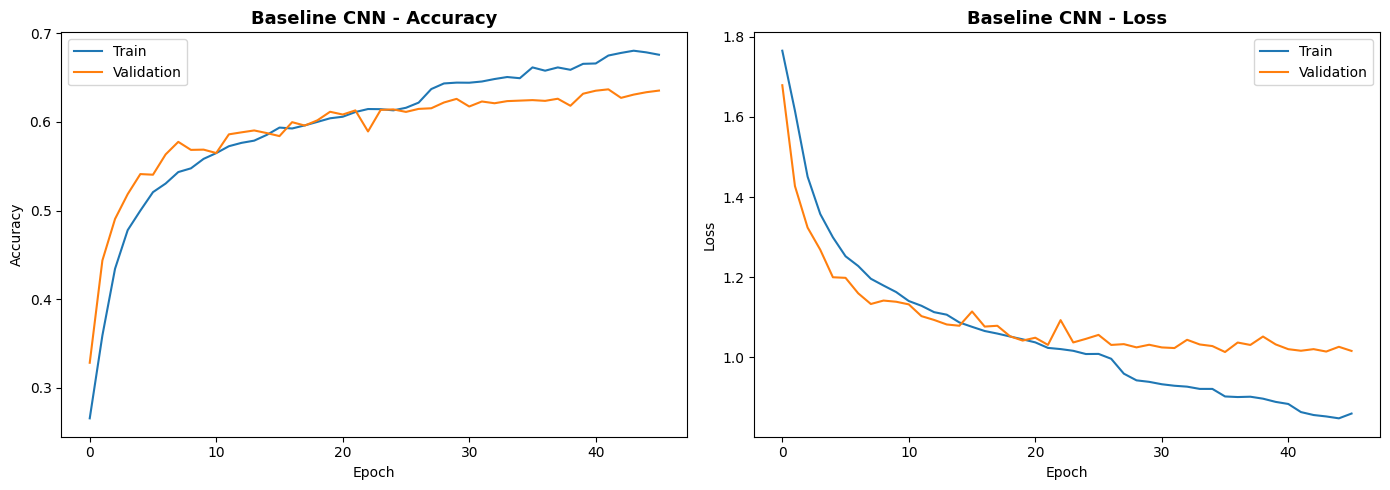

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step

Evaluation Report : Baseline CNN
Test Accuracy     : 57.21%
              precision    recall  f1-score   support

       angry       0.51      0.53      0.52       300
     disgust       0.89      0.33      0.48       100
        fear       0.49      0.34      0.40       300
       happy       0.68      0.86      0.76       300
     neutral       0.49      0.64      0.56       300
         sad       0.44      0.44      0.44       300
    surprise       0.78      0.70      0.74       300

    accuracy                           0.57      1900
   macro avg       0.61      0.55      0.56      1900
weighted avg       0.58      0.57      0.56      1900



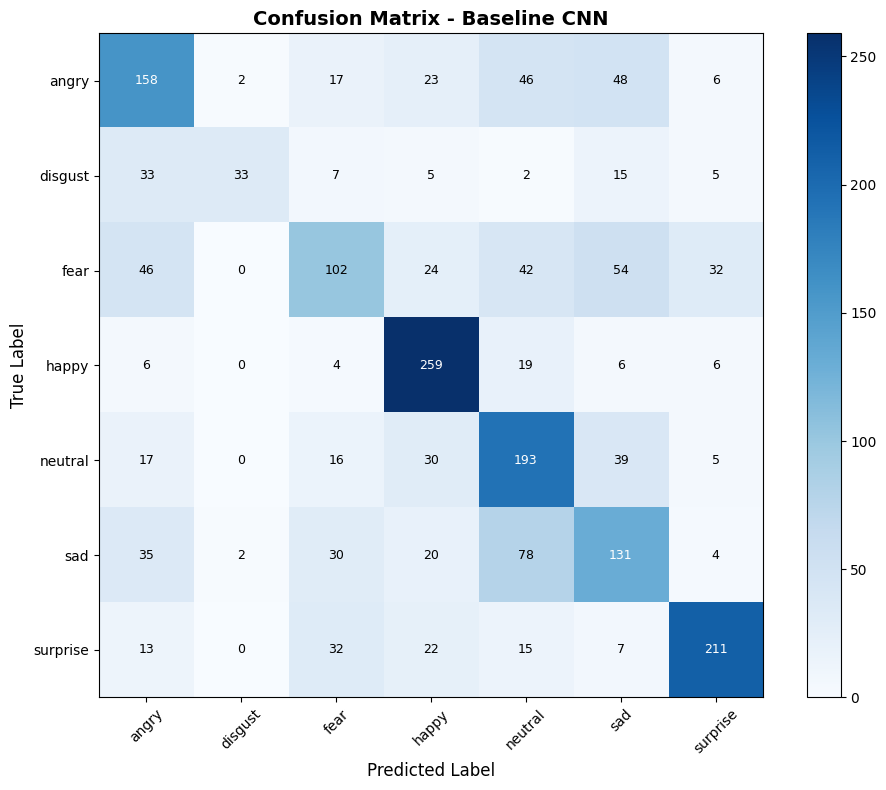

Baseline model saved


In [18]:

baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = make_train_callbacks(
    patience=10,
    lr_patience=5,
    min_lr=1e-6
)

start_time       = time.time()
history_baseline = baseline.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks_baseline
)
baseline_time = time.time() - start_time

print(f'Baseline training time : {baseline_time:.1f} seconds')
plot_history(history_baseline, 'Baseline CNN')
y_true_b, y_pred_b, acc_b = evaluate_model(
    baseline, test_generator, classes, 'Baseline CNN')
baseline.save('baseline_cnn.h5')
print('Baseline model saved')


In [19]:

from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Activation, GlobalAveragePooling2D


def conv_block(x, filters, repeats=2, dropout=0.25, name='block'):
    """Convolution block used by the regularized deeper CNN."""
    for i in range(repeats):
        x = Conv2D(filters, (3, 3), padding='same', name=f'{name}_conv{i + 1}')(x)
        x = BatchNormalization(name=f'{name}_bn{i + 1}')(x)
        x = Activation('relu', name=f'{name}_relu{i + 1}')(x)
    x = MaxPooling2D(2, 2, name=f'{name}_pool')(x)
    x = Dropout(dropout, name=f'{name}_dropout')(x)
    return x


def build_deeper(num_classes):
    """Build a compact regularized CNN for FER-style 48x48 images.

    This version keeps the four convolutional stages but uses global average
    pooling and moderate regularization so the classifier head does not dominate
    the tiny input images.
    """
    inputs = Input(shape=(48, 48, 3), name='image_input')

    x = conv_block(inputs, 32,  repeats=2, dropout=0.25, name='stage1')
    x = conv_block(x,      64,  repeats=2, dropout=0.25, name='stage2')
    x = conv_block(x,      128, repeats=2, dropout=0.25, name='stage3')
    x = conv_block(x,      256, repeats=1, dropout=0.30, name='stage4')

    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.L2(1e-4),
              name='classifier_dense1')(x)
    x = Dropout(0.50, name='classifier_dropout1')(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.L2(1e-4),
              name='classifier_dense2')(x)
    x = Dropout(0.40, name='classifier_dropout2')(x)
    x = Dense(128, activation='relu', name='classifier_dense3')(x)
    outputs = Dense(num_classes, activation='softmax', name='emotion_output')(x)

    return Model(inputs, outputs, name='Regularized_Deeper_CNN')


deeper = build_deeper(NUM_CLASSES)
deeper.summary()


Model: "Regularized_Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv1 (Conv2D)           │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn1 (BatchNormalization) │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_conv2 (Conv2D)           │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_bn2 (BatchNormalization) │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_relu2 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_pool (MaxPooling2D)      │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_dropout (Dropout)        │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv1 (Conv2D)           │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn1 (BatchNormalization) │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_conv2 (Conv2D)           │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_bn2 (BatchNormalization) │ (None, 24, 24, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_relu2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_pool (MaxPooling2D)      │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_dropout (Dropout)        │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv1 (Conv2D)           │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn1 (BatchNormalization) │ (None, 12, 12, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_relu1 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_conv2 (Conv2D)           │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_bn2 (BatchNormalization) │ (None, 12, 12, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_relu2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_pool (MaxPooling2D)      │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_dropout (Dropout)        │ (None, 6, 6, 128)      │             

 Total params: 881,703 (3.36 MB)

 Trainable params: 880,295 (3.36 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.2403 - loss: 1.8705 - val_accuracy: 0.2386 - val_loss: 1.8986 - learning_rate: 3.0000e-04
Epoch 2/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.2821 - loss: 1.7925 - val_accuracy: 0.2672 - val_loss: 2.0911 - learning_rate: 3.0000e-04
Epoch 3/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.3431 - loss: 1.6847 - val_accuracy: 0.3098 - val_loss: 2.1379 - learning_rate: 3.0000e-04
Epoch 4/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4039 - loss: 1.5726 - val_accuracy: 0.4149 - val_loss: 1.6490 - learning_rate: 3.0000e-04
Epoch 5/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.4348 - loss: 1.4963 - val_accuracy: 0.4424 - val_loss: 1.5062 - learning_rate: 3.0000e-04
Epoch 6/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.4618 - loss: 1.4477 - val_accuracy: 0.4257 - val_loss: 1.6220 - learning_rate: 3.0000e-04
Epoch 7/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/ste

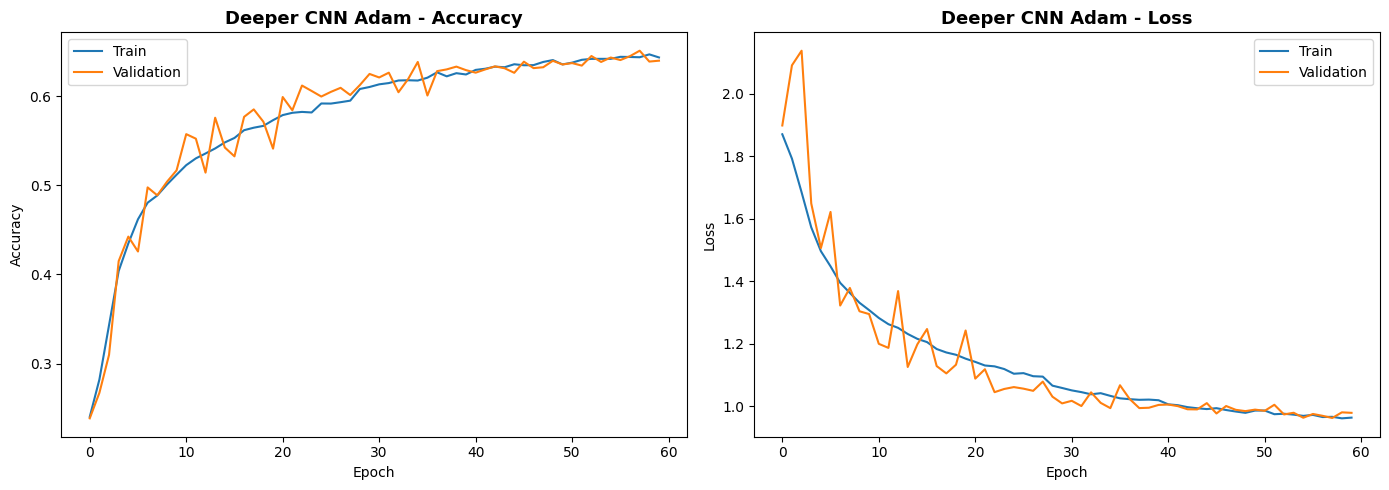

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step

Evaluation Report : Deeper CNN Adam
Test Accuracy     : 60.26%
              precision    recall  f1-score   support

       angry       0.54      0.56      0.55       300
     disgust       0.93      0.14      0.24       100
        fear       0.53      0.27      0.36       300
       happy       0.80      0.89      0.84       300
     neutral       0.48      0.76      0.59       300
         sad       0.49      0.53      0.51       300
    surprise       0.78      0.77      0.78       300

    accuracy                           0.60      1900
   macro avg       0.65      0.56      0.55      1900
weighted avg       0.62      0.60      0.58      1900



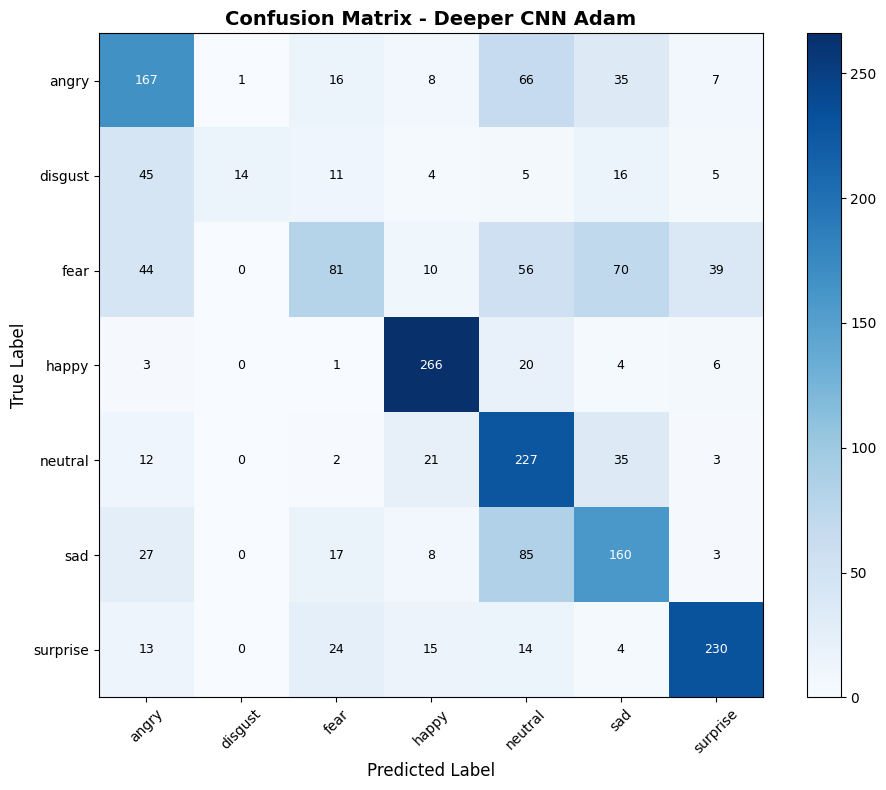

Deeper CNN model saved


In [20]:

deeper.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = make_train_callbacks(
    patience=10,
    lr_patience=5,
    min_lr=1e-7
)

start_time     = time.time()
history_deeper = deeper.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks_deeper
)
deeper_time = time.time() - start_time

print(f'Deeper CNN training time : {deeper_time:.1f} seconds')
plot_history(history_deeper, 'Deeper CNN Adam')
y_true_d, y_pred_d, acc_d = evaluate_model(
    deeper, test_generator, classes, 'Deeper CNN Adam')
deeper.save('deeper_cnn_adam.h5')
print('Deeper CNN model saved')


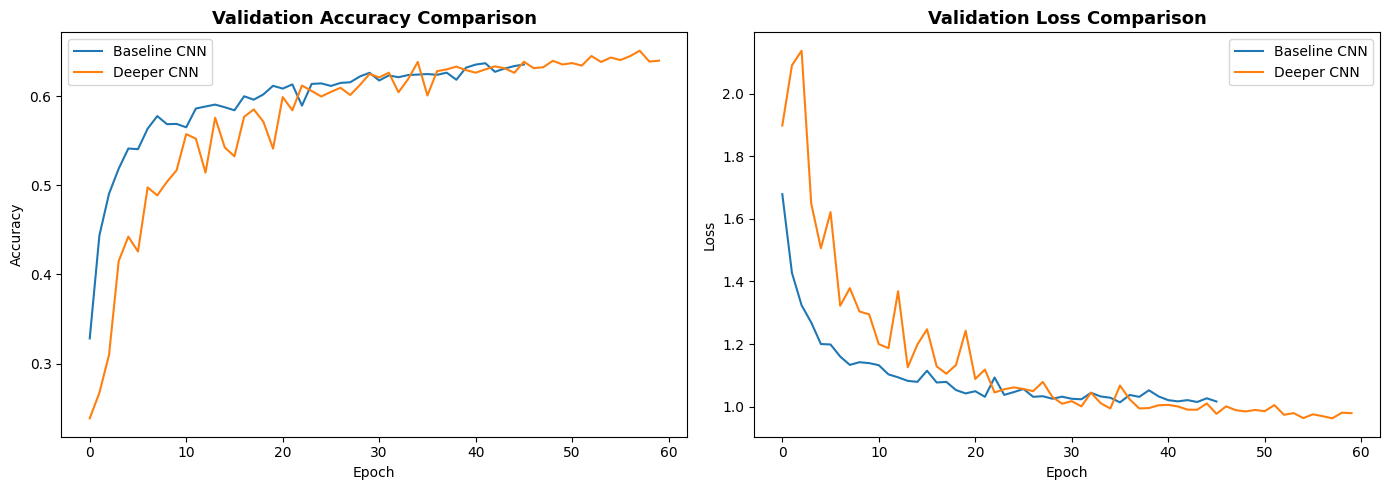

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN')
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper CNN')
axes[0].set_title('Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN')
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper CNN')
axes[1].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150)
plt.show()

Epoch 1/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.2392 - loss: 1.8814 - val_accuracy: 0.2584 - val_loss: 1.8708 - learning_rate: 0.0050
Epoch 2/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.2588 - loss: 1.8460 - val_accuracy: 0.2219 - val_loss: 1.8869 - learning_rate: 0.0050
Epoch 3/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.2748 - loss: 1.8179 - val_accuracy: 0.2952 - val_loss: 1.8134 - learning_rate: 0.0050
Epoch 4/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.3017 - loss: 1.7783 - val_accuracy: 0.2594 - val_loss: 2.3510 - learning_rate: 0.0050
Epoch 5/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.3188 - loss: 1.7356 - val_accuracy: 0.2961 - val_loss: 1.8901 - learning_rate: 0.0050
Epoch 6/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.3345 - loss: 1.6990 - val_accuracy: 0.2731 - val_loss: 2.3751 - learning_rate: 0.0050
Epoch 7/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3560 - l

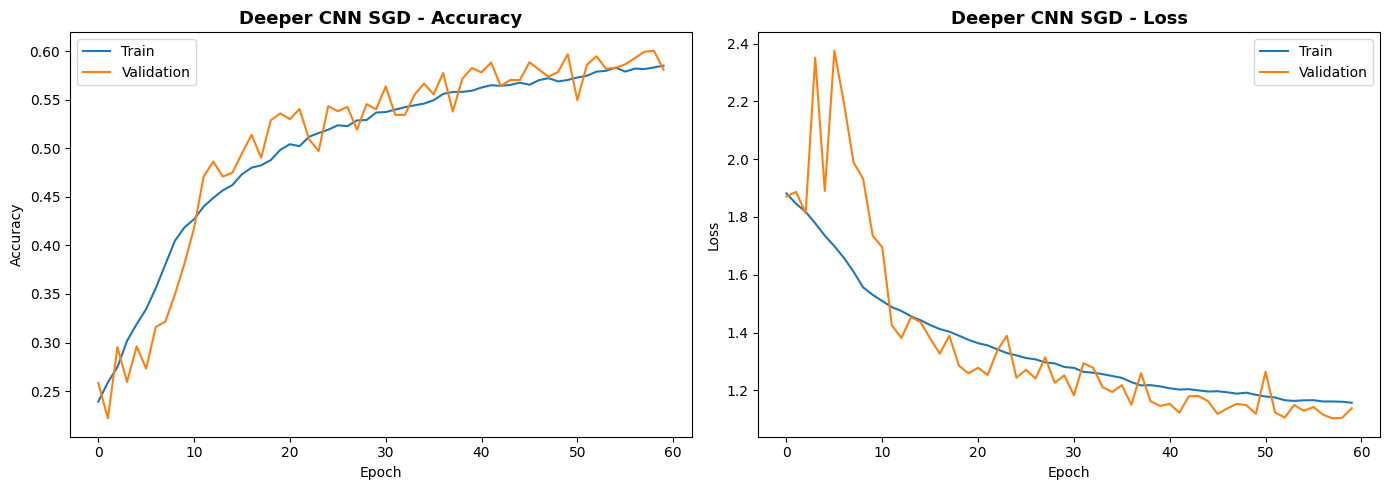

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step

Evaluation Report : Deeper CNN SGD
Test Accuracy     : 53.05%
              precision    recall  f1-score   support

       angry       0.47      0.48      0.47       300
     disgust       0.00      0.00      0.00       100
        fear       0.37      0.15      0.21       300
       happy       0.73      0.82      0.77       300
     neutral       0.44      0.67      0.53       300
         sad       0.40      0.48      0.44       300
    surprise       0.73      0.76      0.74       300

    accuracy                           0.53      1900
   macro avg       0.45      0.48      0.45      1900
weighted avg       0.49      0.53      0.50      1900



/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


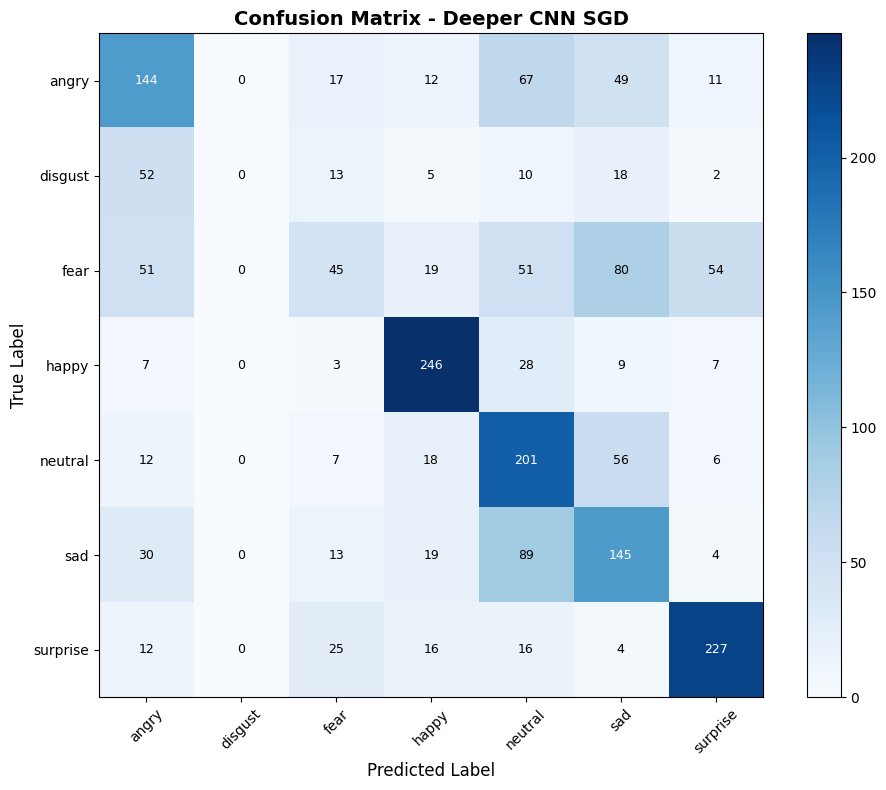

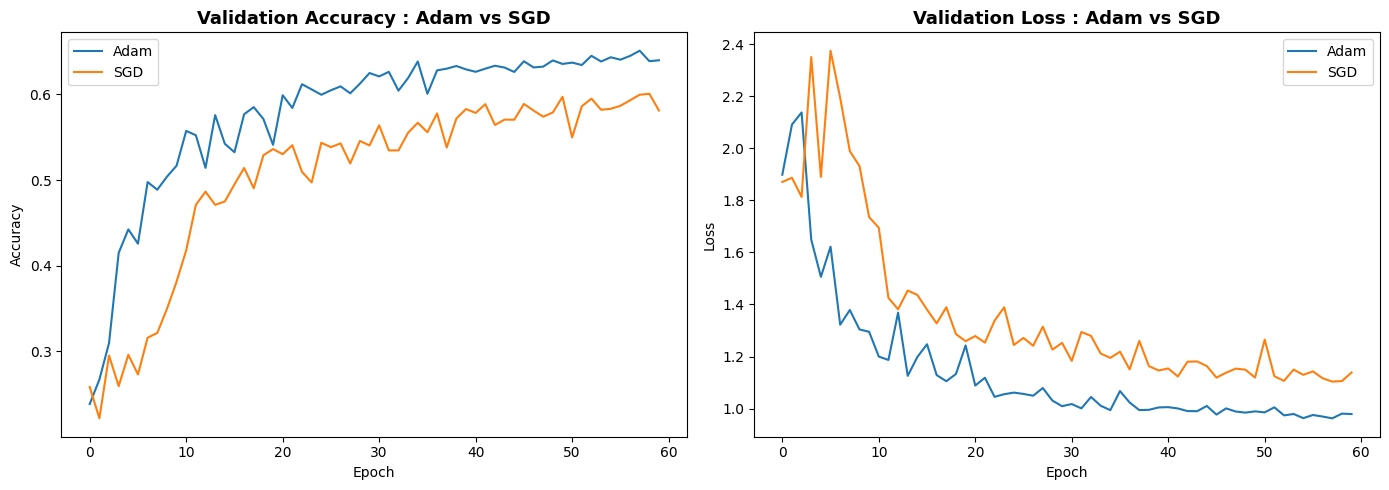

In [22]:

deeper_sgd = build_deeper(NUM_CLASSES)
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.005, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = make_train_callbacks(
    patience=10,
    lr_patience=5,
    min_lr=1e-6
)

start_time  = time.time()
history_sgd = deeper_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks_sgd
)
sgd_time = time.time() - start_time

print(f'SGD training time : {sgd_time:.1f} seconds')
plot_history(history_sgd, 'Deeper CNN SGD')
y_true_s, y_pred_s, acc_s = evaluate_model(
    deeper_sgd, test_generator, classes, 'Deeper CNN SGD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deeper.history['val_accuracy'], label='Adam')
axes[0].plot(history_sgd.history['val_accuracy'],    label='SGD')
axes[0].set_title('Validation Accuracy : Adam vs SGD',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_deeper.history['val_loss'], label='Adam')
axes[1].plot(history_sgd.history['val_loss'],    label='SGD')
axes[1].set_title('Validation Loss : Adam vs SGD',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150)
plt.show()


/root/ai/tfenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.3487 - loss: 1.6596 - val_accuracy: 0.4117 - val_loss: 1.4778 - learning_rate: 0.0010
Epoch 2/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.4964 - loss: 1.3114 - val_accuracy: 0.5323 - val_loss: 1.2232 - learning_rate: 0.0010
Epoch 3/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5404 - loss: 1.2072 - val_accuracy: 0.5218 - val_loss: 1.2729 - learning_rate: 0.0010
Epoch 4/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5617 - loss: 1.1417 - val_accuracy: 0.5668 - val_loss: 1.1488 - learning_rate: 0.0010
Epoch 5/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.5854 - loss: 1.0945 - val_accuracy: 0.5849 - val_loss: 1.1199 - learning_rate: 0.0010
Epoch 6/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5952 - loss: 1.0617 - val_accuracy: 0.5648 - val_loss: 1.1608 - learning_rate: 0.0010
Epoch 7/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6078 - l

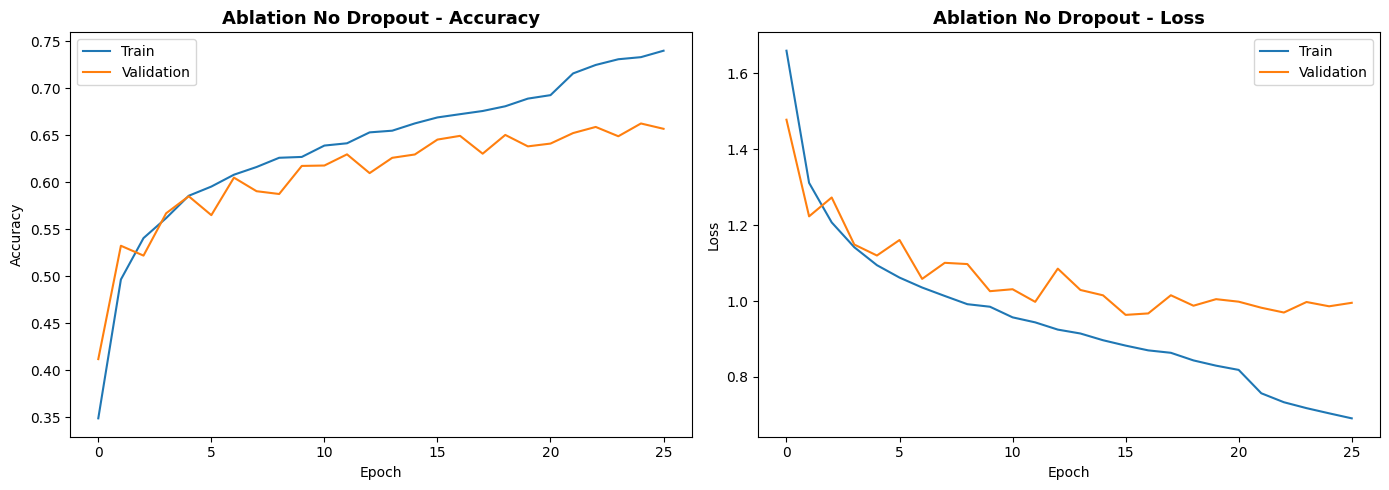

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step

Evaluation Report : Ablation No Dropout
Test Accuracy     : 60.26%
              precision    recall  f1-score   support

       angry       0.55      0.56      0.55       300
     disgust       0.84      0.32      0.46       100
        fear       0.51      0.38      0.44       300
       happy       0.71      0.89      0.79       300
     neutral       0.50      0.72      0.59       300
         sad       0.50      0.46      0.48       300
    surprise       0.84      0.69      0.76       300

    accuracy                           0.60      1900
   macro avg       0.64      0.58      0.58      1900
weighted avg       0.61      0.60      0.59      1900



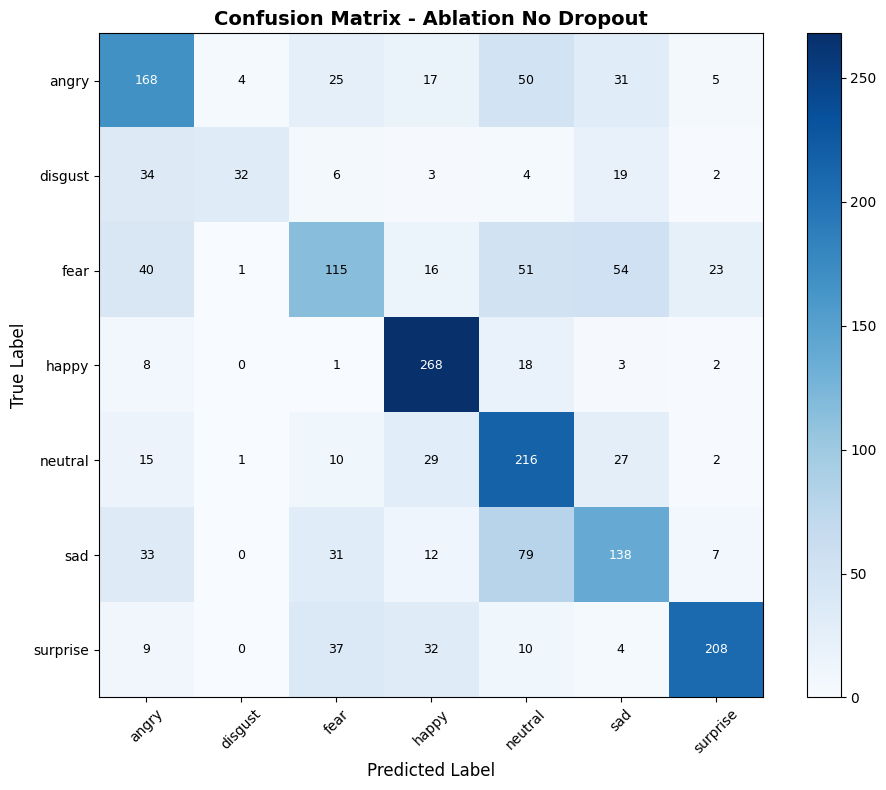

In [23]:
def build_no_dropout(num_classes):
    """Deeper CNN without dropout for ablation study."""
    model = Sequential([
        Conv2D(32,  (3, 3), activation='relu', padding='same',
               input_shape=(48, 48, 3)),
        BatchNormalization(),
        Conv2D(32,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64,  (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='No_Dropout_Ablation')
    return model

ablation = build_no_dropout(NUM_CLASSES)
ablation.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ablation = make_train_callbacks(
    patience=10,
    lr_patience=5,
    min_lr=1e-6
)

history_ablation = ablation.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=callbacks_ablation
)

plot_history(history_ablation, 'Ablation No Dropout')
_, _, acc_abl = evaluate_model(
    ablation, test_generator, classes, 'Ablation No Dropout')


In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input

IMG_RESNET   = (224, 224)
BATCH_RESNET = 32

rn_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
).flow_from_directory(
    train_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical'
)

rn_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical',
    shuffle=False
)

rn_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_RESNET,
    batch_size=BATCH_RESNET,
    class_mode='categorical',
    shuffle=False
)

base_model           = ResNet50(weights='imagenet', include_top=False,
                                input_shape=(224, 224, 3))
base_model.trainable = False

inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(512, activation='relu')(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs, outputs, name='ResNet50_FER')
resnet_model.summary()

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


Model: "ResNet50_FER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,975 (94.50 MB)

 Trainable params: 1,183,239 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

Epoch 1/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 172s 187ms/step - accuracy: 0.3031 - loss: 1.7716 - val_accuracy: 0.2579 - val_loss: 4.1387 - learning_rate: 0.0010
Epoch 2/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 147s 175ms/step - accuracy: 0.3429 - loss: 1.6558 - val_accuracy: 0.3038 - val_loss: 2.9823 - learning_rate: 0.0010
Epoch 3/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 159s 189ms/step - accuracy: 0.3557 - loss: 1.6304 - val_accuracy: 0.2639 - val_loss: 4.5872 - learning_rate: 0.0010
Epoch 4/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 159s 189ms/step - accuracy: 0.3627 - loss: 1.6116 - val_accuracy: 0.2334 - val_loss: 3.5326 - learning_rate: 0.0010
Epoch 5/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 147s 175ms/step - accuracy: 0.3652 - loss: 1.6060 - val_accuracy: 0.3089 - val_loss: 2.2344 - learning_rate: 0.0010
Epoch 6/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 152s 181ms/step - accuracy: 0.3688 - loss: 1.6005 - val_accuracy: 0.1930 - val_loss: 3.0186 - learning_rate: 0.0010
Epoch 7/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 138s 164ms/step - accuracy: 0.3

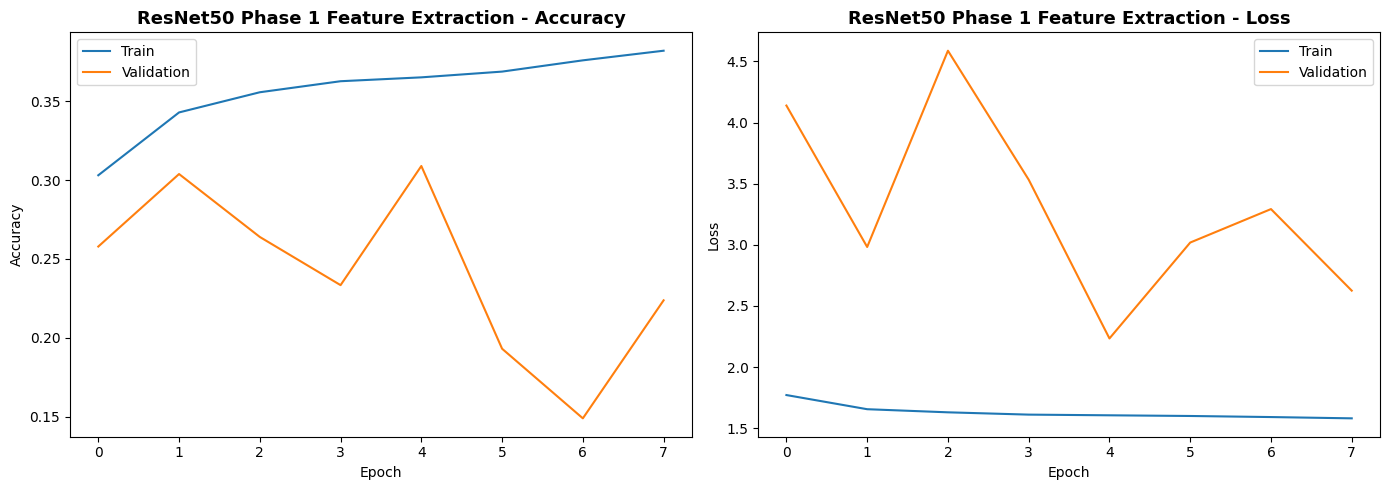

In [26]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_resnet_p1 = make_train_callbacks(
    patience=8,
    lr_patience=4,
    min_lr=1e-7
)

start_time = time.time()
history_p1 = resnet_model.fit(
    rn_train_gen,
    validation_data=rn_val_gen,
    epochs=8,
    callbacks=callbacks_resnet_p1
)
print(f'Phase 1 training time : {time.time() - start_time:.1f} seconds')
plot_history(history_p1, 'ResNet50 Phase 1 Feature Extraction')


Epoch 1/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 171s 183ms/step - accuracy: 0.3413 - loss: 1.6933 - val_accuracy: 0.3130 - val_loss: 1.7663 - learning_rate: 1.0000e-05
Epoch 2/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 139s 165ms/step - accuracy: 0.3819 - loss: 1.5921 - val_accuracy: 0.3442 - val_loss: 1.9362 - learning_rate: 1.0000e-05
Epoch 3/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 154s 183ms/step - accuracy: 0.4002 - loss: 1.5534 - val_accuracy: 0.4382 - val_loss: 1.4688 - learning_rate: 1.0000e-05
Epoch 4/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 152s 181ms/step - accuracy: 0.4026 - loss: 1.5392 - val_accuracy: 0.3503 - val_loss: 1.7159 - learning_rate: 1.0000e-05
Epoch 5/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 138s 165ms/step - accuracy: 0.4128 - loss: 1.5180 - val_accuracy: 0.3449 - val_loss: 2.4068 - learning_rate: 1.0000e-05
Epoch 6/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 154s 183ms/step - accuracy: 0.4190 - loss: 1.5019 - val_accuracy: 0.4263 - val_loss: 1.4638 - learning_rate: 1.0000e-05
Epoch 7/8
840/840 ━━━━━━━━━━━━━━━━━━━━ 145s 17

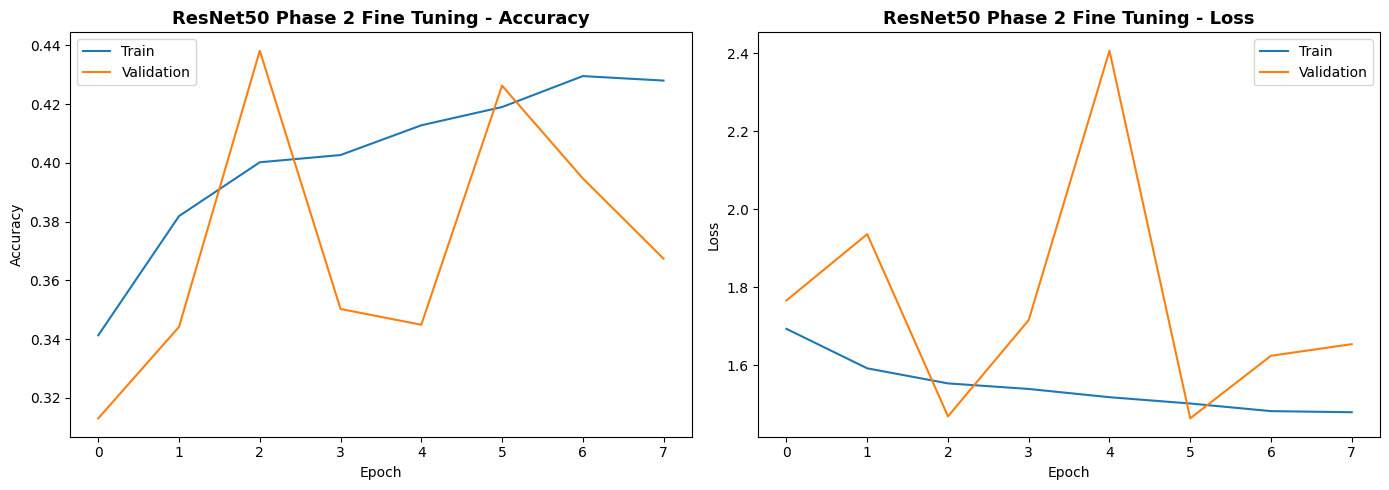

60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 162ms/step

Evaluation Report : ResNet50 Transfer Learning
Test Accuracy     : 37.26%
              precision    recall  f1-score   support

       angry       0.34      0.13      0.18       300
     disgust       0.00      0.00      0.00       100
        fear       0.31      0.06      0.10       300
       happy       0.40      0.75      0.53       300
     neutral       0.29      0.67      0.41       300
         sad       0.38      0.05      0.08       300
    surprise       0.48      0.71      0.57       300

    accuracy                           0.37      1900
   macro avg       0.32      0.34      0.27      1900
weighted avg       0.35      0.37      0.29      1900



/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/ai/tfenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


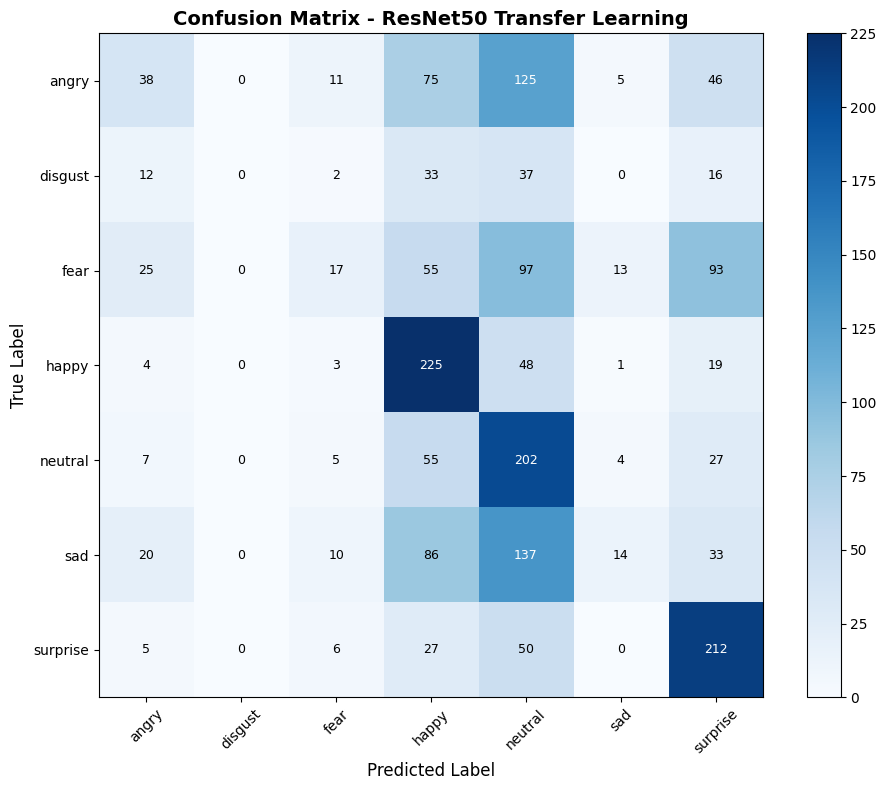

ResNet50 model saved


In [27]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_resnet_p2 = make_train_callbacks(
    patience=8,
    lr_patience=4,
    min_lr=1e-7
)

start_time = time.time()
history_p2 = resnet_model.fit(
    rn_train_gen,
    validation_data=rn_val_gen,
    epochs=8,
    callbacks=callbacks_resnet_p2
)
print(f'Phase 2 training time : {time.time() - start_time:.1f} seconds')
plot_history(history_p2, 'ResNet50 Phase 2 Fine Tuning')
y_true_r, y_pred_r, acc_r = evaluate_model(
    resnet_model, rn_test_gen, classes, 'ResNet50 Transfer Learning')
resnet_model.save('resnet50_fer.h5')
print('ResNet50 model saved')


Final Model Comparison
Model                       Test Accuracy
  Baseline CNN            : 57.21%
  Deeper CNN Adam         : 60.26%
  Deeper CNN SGD          : 53.05%
  Ablation Study          : 60.26%
  ResNet50 Transfer       : 37.26%


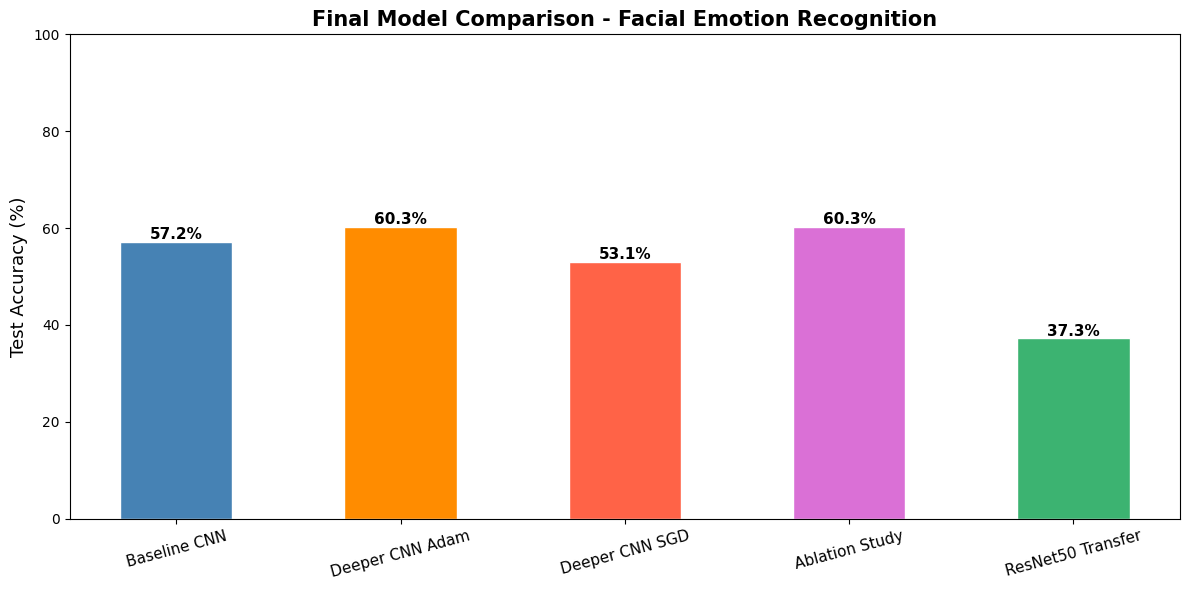

In [28]:
summary = {
    'Baseline CNN'      : acc_b,
    'Deeper CNN Adam'   : acc_d,
    'Deeper CNN SGD'    : acc_s,
    'Ablation Study'    : acc_abl,
    'ResNet50 Transfer' : acc_r,
}

print('Final Model Comparison')
print(f'{"Model":<25} {"Test Accuracy":>15}')
for name, acc in summary.items():
    print(f'  {name:<23} : {acc * 100:.2f}%')

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['steelblue', 'darkorange', 'tomato', 'orchid', 'mediumseagreen']
bars    = ax.bar(summary.keys(), [v * 100 for v in summary.values()],
                 color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, summary.values()):
    ax.text(bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.5,
            f'{acc * 100:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Final Model Comparison - Facial Emotion Recognition',
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()